# Phase 1 — Project C: Build a GPT from Scratch

**Goal**: Build a character-level language model from the ground up. Every single hyperparameter — `n_layers`, `n_heads`, `d_model`, `d_ff`, `context_len` — will be *your choice*, justified by reasoning, not copied from a paper.

**Dataset**: Shakespeare's complete works (~1MB of text). Small enough to train on MPS in minutes per epoch, rich enough to produce visibly coherent output.

**The central questions this project answers**:
- Why is `d_ff = 4 * d_model`?
- Why does `d_head = d_model / n_heads`?
- What does each component (attention, FFN, LayerNorm, positional encoding) actually *do*?
- When does depth help vs. when does width help?
- Why can't you just use a very long context window?

**What you will implement** (in order):
1. Data pipeline: tokenizer, dataset, batching
2. Multi-head self-attention (the core)
3. Feed-forward block
4. Transformer block (attention + FFN + residuals + LayerNorm)
5. Full GPT model
6. Training loop with gradient clipping and LR warmup
7. Text generation (greedy and temperature sampling)
8. Ablation experiments: depth vs. width, with/without positional encoding, with/without causal mask

**Reference**: Andrej Karpathy's nanoGPT is the gold standard. Do NOT look at it until you have finished your own implementation. Then compare yours to his — the differences will teach you more than copying would.

---
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import time
import copy
import requests
from pathlib import Path
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

Device: cuda


In [2]:
# Download Shakespeare data
DATA_PATH = Path('data/shakespeare.txt')
DATA_PATH.parent.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    url  = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    text = requests.get(url).text
    DATA_PATH.write_text(text)
    print(f'Downloaded {len(text):,} characters')
else:
    text = DATA_PATH.read_text()
    print(f'Loaded {len(text):,} characters')

print('\nFirst 300 characters:')
print(text[:300])

Downloaded 1,115,394 characters

First 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


---
## Section 1 — Tokenizer and data pipeline

We use **character-level tokenization** — the vocabulary is just the set of unique characters in the text. This keeps `vocab_size` small (~65 for Shakespeare) so the model can be tiny but still produce readable output.

Real LLMs use subword tokenizers (BPE, SentencePiece) with vocabularies of 32k–100k tokens. The mechanics of training and generation are identical — only the vocabulary size changes.

### ✏️ TASK 1.1 — Implement `CharTokenizer`

**What it does**: builds a character-to-index mapping and provides `encode`/`decode` methods.

**Arguments to `__init__`**:
- `text` (`str`): the full corpus. Vocabulary is built from all unique characters in this text.

**Attributes to set**:
- `self.vocab_size` (`int`): number of unique characters
- `self.stoi` (`dict`): char → int
- `self.itos` (`dict`): int → char

**Methods**:
- `encode(s: str) -> list[int]`: convert string to list of token ids
- `decode(ids: list[int]) -> str`: convert list of ids back to string

In [3]:
class CharTokenizer:
    """
    Character-level tokenizer.

    Attributes:
        vocab_size (int)
        stoi (dict): char -> int
        itos (dict): int -> char
    """
    def __init__(self, text):
        # YOUR CODE HERE
        # Hint: sorted(set(text)) gives all unique chars in sorted order
        self.vocab = sorted(set(text))
        self.vocab_size = len(self.vocab)
        self.itos = {i:ch for i,ch in enumerate(self.vocab)}
        self.stoi = {ch:i for i,ch in self.itos.items()}

    def encode(self, s):
        """str -> list[int]"""
        # YOUR CODE HERE
        return [self.stoi[c] for c in s]

    def decode(self, ids):
        """list[int] -> str"""
        # YOUR CODE HERE
        return ''.join([self.itos[i] for i in ids])

In [4]:
# ── SANITY CHECK 1.1 ───────────────────────────────────────────────────────
tokenizer = CharTokenizer(text)

print(f'Vocab size: {tokenizer.vocab_size}')  # expect ~65
print(f'Vocab: {"".join(sorted(tokenizer.stoi.keys()))}')

sample = 'Hello, World!'
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)

assert decoded == sample, f'Round-trip failed: got "{decoded}"'
assert len(encoded) == len(sample)
assert all(isinstance(i, int) for i in encoded)
assert 50 <= tokenizer.vocab_size <= 80, f'Unexpected vocab size: {tokenizer.vocab_size}'

print(f'encode("{sample}") = {encoded}')
print(f'decode back        = "{decoded}"  ✓')
print('All tokenizer checks passed!')

Vocab size: 65
Vocab: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
encode("Hello, World!") = [20, 43, 50, 50, 53, 6, 1, 35, 53, 56, 50, 42, 2]
decode back        = "Hello, World!"  ✓
All tokenizer checks passed!


### ✏️ TASK 1.2 — Implement `ShakespeareDataset`

**What it does**: slices the tokenized corpus into (input, target) pairs for language modeling.

**The language modeling objective**: given a sequence of `context_len` tokens, predict the *next* token at every position. So:
```
input  = tokens[i   : i + context_len]      shape: (context_len,)
target = tokens[i+1 : i + context_len + 1]  shape: (context_len,)
```
Each position `t` in the input predicts `target[t]` — the next character. This means one sample gives `context_len` training examples at once.

**Arguments to `__init__`**:
- `tokens` (`torch.Tensor`, shape `[N]`, dtype `torch.long`): full encoded corpus
- `context_len` (`int`): sequence length, e.g. 128

**`__getitem__(idx)`**: returns `(x, y)` both `torch.long` tensors of shape `(context_len,)`

In [5]:
class ShakespeareDataset(Dataset):
    """
    Sliding-window dataset for character-level language modeling.

    Args:
        tokens      (Tensor[long]): full encoded text, shape [N]
        context_len (int): number of tokens per sample

    __getitem__ returns (x, y):
        x: tokens[i   : i+context_len]  — input
        y: tokens[i+1 : i+context_len+1] — targets (shifted by 1)
    """
    def __init__(self, tokens, context_len):
        # YOUR CODE HERE
        self.tokens = tokens
        self.context_len =context_len

    def __len__(self):
        # YOUR CODE HERE
        # Hint: how many full windows of size context_len+1 fit in tokens?
        return self.tokens.shape[0] - self.context_len

    def __getitem__(self, idx):
        # YOUR CODE HERE
        x = self.tokens[idx:idx+self.context_len]
        y = self.tokens[idx+1:idx+self.context_len+1]
        return x,y

In [6]:
# ── Build datasets ─────────────────────────────────────────────────────────
all_tokens  = torch.tensor(tokenizer.encode(text), dtype=torch.long)
split_idx   = int(0.9 * len(all_tokens))
train_tokens = all_tokens[:split_idx]
val_tokens   = all_tokens[split_idx:]

CONTEXT_LEN = 128  # we will ablate this later

train_ds = ShakespeareDataset(train_tokens, CONTEXT_LEN)
val_ds   = ShakespeareDataset(val_tokens,   CONTEXT_LEN)

# ── SANITY CHECK 1.2 ───────────────────────────────────────────────────────
x0, y0 = train_ds[0]
assert x0.shape == (CONTEXT_LEN,), f'Expected ({CONTEXT_LEN},), got {x0.shape}'
assert y0.shape == (CONTEXT_LEN,), f'Expected ({CONTEXT_LEN},), got {y0.shape}'
assert x0.dtype == torch.long

# Target must be input shifted by 1
assert torch.all(y0[:-1] == x0[1:]), 'y should equal x shifted left by 1'

print(f'Train tokens  : {len(train_tokens):,}')
print(f'Val tokens    : {len(val_tokens):,}')
print(f'Train samples : {len(train_ds):,}')
print(f'Val samples   : {len(val_ds):,}')
print(f'x[0][:20] decoded: "{tokenizer.decode(x0[:20].tolist())}"')
print(f'y[0][:20] decoded: "{tokenizer.decode(y0[:20].tolist())}"')
print('  (y is x shifted left by 1 — each token predicts the next)  ✓')

Train tokens  : 1,003,854
Val tokens    : 111,540
Train samples : 1,003,726
Val samples   : 111,412
x[0][:20] decoded: "First Citizen:
Befor"
y[0][:20] decoded: "irst Citizen:
Before"
  (y is x shifted left by 1 — each token predicts the next)  ✓


---
## Section 2 — Multi-head self-attention

This is the most important section. Read every docstring and comment carefully before implementing.

### The attention mechanism

Attention computes, for each position, a weighted sum over all other positions. The weights come from a **compatibility score** between a Query (what am I looking for?) and Keys (what does each position offer?).

```
Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_head)) @ V
```

- `Q`, `K`, `V` all have shape `(B, T, d_head)` for one head
- `Q @ K.T` produces shape `(B, T, T)` — one score per pair of positions
- Dividing by `sqrt(d_head)` prevents the dot products from growing too large (which would saturate softmax)
- The result is a weighted average of `V` vectors

**Multi-head**: run `n_heads` attention operations in parallel, each with its own Q/K/V projections but smaller `d_head = d_model / n_heads`. Then concatenate and project back.

**Causal mask**: for language modeling, position `t` cannot attend to positions `t+1, t+2, ...` (future tokens). Enforce this by adding `-inf` to those positions before softmax, so they get weight 0.

### ✏️ TASK 2.1 — Implement `MultiHeadSelfAttention`

**Arguments to `__init__`**:
- `d_model` (`int`): total model dimension (e.g. 128)
- `n_heads` (`int`): number of attention heads (e.g. 4). Must divide `d_model` evenly.
- `context_len` (`int`): max sequence length (used to pre-build the causal mask)
- `dropout` (`float`): applied to attention weights after softmax

**Attributes to set**:
- `self.d_head = d_model // n_heads`
- `self.qkv_proj`: a single `nn.Linear(d_model, 3 * d_model, bias=False)` — projects input to Q, K, V all at once
- `self.out_proj`: `nn.Linear(d_model, d_model, bias=False)` — final output projection
- `self.attn_dropout`: `nn.Dropout(dropout)`
- register a causal mask buffer (see below)

**Causal mask**: a boolean upper-triangular matrix. Register it as a buffer (not a parameter) so it moves to the right device with the model:
```python
mask = torch.triu(torch.ones(context_len, context_len), diagonal=1).bool()
self.register_buffer('causal_mask', mask)
# mask[i, j] = True means position i must NOT attend to position j
```

**Forward pseudocode**:
```
def forward(self, x):          # x shape: (B, T, d_model)
    B, T, _ = x.shape

    # 1. Project to Q, K, V
    qkv = self.qkv_proj(x)     # (B, T, 3 * d_model)
    q, k, v = qkv.split(d_model, dim=-1)  # each: (B, T, d_model)

    # 2. Reshape for multi-head: (B, T, d_model) -> (B, n_heads, T, d_head)
    #    Hint: view(B, T, n_heads, d_head).transpose(1, 2)

    # 3. Compute attention scores
    scale  = math.sqrt(self.d_head)
    scores = (q @ k.transpose(-2, -1)) / scale   # (B, n_heads, T, T)

    # 4. Apply causal mask: set future positions to -inf
    #    self.causal_mask[:T, :T] gives a (T, T) boolean mask
    #    scores = scores.masked_fill(mask, float('-inf'))

    # 5. Softmax + dropout
    weights = F.softmax(scores, dim=-1)  # (B, n_heads, T, T)
    weights = self.attn_dropout(weights)

    # 6. Weighted sum of V
    out = weights @ v            # (B, n_heads, T, d_head)

    # 7. Recombine heads: (B, n_heads, T, d_head) -> (B, T, d_model)
    #    Hint: transpose(1, 2).contiguous().view(B, T, d_model)

    # 8. Final output projection
    return self.out_proj(out)    # (B, T, d_model)
```

In [36]:
class MultiHeadSelfAttention(nn.Module):
    """
    Causal multi-head self-attention.

    Args:
        d_model     (int): total model dimension
        n_heads     (int): number of attention heads
        context_len (int): maximum sequence length (for causal mask)
        dropout     (float): attention weight dropout
    """
    def __init__(self, d_model, n_heads, context_len, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'
        # YOUR CODE HERE
        self.d_head = d_model // n_heads
        self.d_model = d_model
        self.n_heads = n_heads
        self.qkv_proj = nn.Linear(d_model,3*d_model,bias=False)
        self.out_proj = nn.Linear(d_model,d_model,bias=False)
        self.attn_dropout = nn.Dropout(dropout)
        mask = torch.triu(torch.ones((context_len,context_len)),diagonal=1).bool()
        self.register_buffer('causal_mask',mask)

    def forward(self, x):
        """
        Args:
            x: (B, T, d_model)
        Returns:
            out: (B, T, d_model)
        """
        # YOUR CODE HERE
        B,T,_ = x.shape
        qkv = self.qkv_proj(x)
        q,k,v = qkv.split(self.d_model,dim=-1)
        q=q.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        k=k.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        v=v.view(B,T,self.n_heads,self.d_head).transpose(1,2)

        scores = (q @ k.transpose(-2,-1))/math.sqrt(self.d_head)

        scores = scores.masked_fill(self.causal_mask[:T,:T],float('-inf'))

        weights = F.softmax(scores,dim=-1)
        weights = self.attn_dropout(weights)

        attn_probs = F.softmax(scores.masked_fill(self.causal_mask[:T, :T], float('-inf')), dim=-1)
        attn_probs = self.attn_dropout(attn_probs)
        self.last_attn_weights = attn_probs  # (1, n_heads, T, T)

        out = weights @ v
        out = out.transpose(1,2).contiguous().view(B,T,self.d_model)
        return self.out_proj(out)


In [8]:
# ── SANITY CHECK 2.1 ───────────────────────────────────────────────────────
B, T, D = 4, 16, 64
attn = MultiHeadSelfAttention(d_model=D, n_heads=4, context_len=T, dropout=0.0)
x    = torch.randn(B, T, D)
out  = attn(x)

assert out.shape == (B, T, D), f'Expected {(B,T,D)}, got {out.shape}'
print(f'Output shape: {out.shape}  ✓')

# Test 1: causal mask — output at position t should not depend on position t+1
# Perturb x at position T-1 and check that position 0's output does not change
x2         = x.clone()
x2[:, -1, :] += 100.0   # large perturbation at the last position
out2 = attn(x)
out3 = attn(x2)
# Position 0 output should be identical — it cannot attend to position T-1
assert torch.allclose(out2[:, 0, :], out3[:, 0, :], atol=1e-4), \
    'Causal mask broken: position 0 output changed when last position was perturbed!'
print(f'Causal mask verified: pos-0 output unchanged when last token perturbed  ✓')

# Test 2: d_head is correct
assert attn.d_head == D // 4
print(f'd_head = {attn.d_head}  (= d_model / n_heads = {D} / 4)  ✓')

# Test 3: parameter count — should be 4 * d_model^2 (qkv_proj=3D^2, out_proj=D^2)
n_params = sum(p.numel() for p in attn.parameters())
expected = 4 * D * D
assert n_params == expected, f'Expected {expected} params, got {n_params}'
print(f'Parameter count: {n_params} = 4 × d_model²  ✓')

print('\nAll attention sanity checks passed!')

Output shape: torch.Size([4, 16, 64])  ✓
Causal mask verified: pos-0 output unchanged when last token perturbed  ✓
d_head = 16  (= d_model / n_heads = 64 / 4)  ✓
Parameter count: 16384 = 4 × d_model²  ✓

All attention sanity checks passed!


**Before moving on, answer these questions:**

1. Why do we scale by `1/sqrt(d_head)` and not `1/d_head` or `1/d_model`?
   Hint: if Q and K have unit-variance entries, what is the variance of their dot product?

2. We use a single `qkv_proj` matrix that produces Q, K, V all at once. Why is this equivalent to three separate projections? What is the computational advantage?

3. What happens to the attention pattern if you remove the causal mask during language model *training*? Would the loss still go down? Would generation work?

4. If `d_model=128` and `n_heads=4`, each head has `d_head=32`. If you instead used 8 heads, each head has `d_head=16`. The total parameters stay the same. What changes? What might be the tradeoff?

*(Your answers here)*

---
## Section 3 — Feed-forward block

### ✏️ TASK 3.1 — Implement `FeedForward`

**What it does**: A two-layer MLP applied independently to each position. This is the "thinking" step — after attention gathers information from other positions, the FFN processes it per-token.

**Architecture**:
```
Linear(d_model, d_ff)   # expand
GELU()                  # activation
Dropout(p)
Linear(d_ff, d_model)   # contract
Dropout(p)
```

**Arguments**:
- `d_model` (`int`)
- `d_ff` (`int`): inner dimension. The standard choice is `d_ff = 4 * d_model`. You will verify this in the ablation section.
- `dropout` (`float`)

> **Why GELU instead of ReLU?** GELU (Gaussian Error Linear Unit) has a smooth, non-zero gradient near 0, which empirically works better in transformers. GPT-2 and most modern LLMs use GELU. ReLU will also work but slightly worse.

In [9]:
class FeedForward(nn.Module):
    """
    Position-wise feed-forward network.

    Args:
        d_model (int): input/output dimension
        d_ff    (int): inner (expanded) dimension, typically 4 * d_model
        dropout (float)
    """
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.model = nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff,d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        """
        Args:
            x: (B, T, d_model)
        Returns:
            out: (B, T, d_model)
        """
        # YOUR CODE HERE
        return self.model(x)

In [10]:
# ── SANITY CHECK 3.1 ───────────────────────────────────────────────────────
ffn = FeedForward(d_model=64, d_ff=256, dropout=0.1)
x   = torch.randn(4, 16, 64)
out = ffn(x)

assert out.shape == x.shape, f'FFN must preserve shape. Got {out.shape}'
print(f'FeedForward output shape: {out.shape}  (same as input)  ✓')

# Parameter count: d_model*d_ff + d_ff + d_ff*d_model + d_model (with bias)
n = sum(p.numel() for p in ffn.parameters())
expected_no_bias = 2 * 64 * 256
print(f'Parameters: {n} (with bias: {n}, without bias would be {expected_no_bias})')

print('FeedForward sanity check passed!  ✓')

FeedForward output shape: torch.Size([4, 16, 64])  (same as input)  ✓
Parameters: 33088 (with bias: 33088, without bias would be 32768)
FeedForward sanity check passed!  ✓


---
## Section 4 — Transformer block

### ✏️ TASK 4.1 — Implement `TransformerBlock`

**What it does**: One complete transformer layer — attention followed by FFN, each wrapped with a residual connection and LayerNorm.

**Architecture — Pre-LN style (modern convention)**:
```
x = x + Attention(LayerNorm(x))   # sublayer 1
x = x + FFN(LayerNorm(x))         # sublayer 2
```

This is called **Pre-LN** because LayerNorm is applied *before* each sublayer. The original "Attention is All You Need" paper uses Post-LN (norm after the residual addition). Pre-LN is more stable and is used in GPT-2 and later.

**Arguments**:
- `d_model` (`int`)
- `n_heads` (`int`)
- `d_ff` (`int`)
- `context_len` (`int`)
- `dropout` (`float`)

**Attributes**:
- `self.ln1`, `self.ln2`: two `nn.LayerNorm(d_model)` instances
- `self.attn`: `MultiHeadSelfAttention`
- `self.ffn`: `FeedForward`
- `self.dropout`: `nn.Dropout(dropout)` — applied to sublayer outputs before adding to residual

In [11]:
class TransformerBlock(nn.Module):
    """
    One transformer layer: Pre-LN attention + Pre-LN FFN, both with residuals.

    Args:
        d_model     (int)
        n_heads     (int)
        d_ff        (int): FFN inner dim, typically 4 * d_model
        context_len (int)
        dropout     (float)
    """
    def __init__(self, d_model, n_heads, d_ff, context_len, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.attn = MultiHeadSelfAttention(d_model,n_heads,context_len,dropout)
        self.ffn =FeedForward(d_model,d_ff,dropout)
        self.dropout = nn.Dropout(dropout)
        self.ln1=nn.LayerNorm(d_model)
        self.ln2=nn.LayerNorm(d_model)

    def forward(self, x):
        """
        Args:
            x: (B, T, d_model)
        Returns:
            x: (B, T, d_model)  — same shape
        """
        # Pseudocode:
        # x = x + self.dropout(self.attn(self.ln1(x)))
        # x = x + self.dropout(self.ffn(self.ln2(x)))
        # return x
        # YOUR CODE HERE
        x = x + self.dropout(self.attn(self.ln1(x)))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x

In [12]:
# ── SANITY CHECK 4.1 ───────────────────────────────────────────────────────
block = TransformerBlock(d_model=64, n_heads=4, d_ff=256, context_len=32, dropout=0.1)
x     = torch.randn(4, 32, 64)
out   = block(x)

assert out.shape == x.shape, f'Block must preserve shape. Got {out.shape}'
print(f'TransformerBlock output shape: {out.shape}  ✓')

# Residual connection test: with zero-init weights the output should be close to input
# (not exact because LayerNorm changes the scale, but the skip path means output ≈ input)
block_test = TransformerBlock(d_model=8, n_heads=2, d_ff=32, context_len=4)
for p in block_test.parameters():
    p.data.zero_()
x_small  = torch.randn(2, 4, 8)
out_test = block_test(x_small)
# With zeroed weights, attention and FFN output zeros, so x = x + 0 = x
assert torch.allclose(out_test, x_small, atol=1e-5), \
    'With zero weights, block should act as identity (residual connection)'
print('Residual connection verified (zero weights → identity)  ✓')

# Count params in one block
n = sum(p.numel() for p in block.parameters())
print(f'Params per block (d_model=64, n_heads=4, d_ff=256): {n:,}')
print('TransformerBlock sanity check passed!')

TransformerBlock output shape: torch.Size([4, 32, 64])  ✓
Residual connection verified (zero weights → identity)  ✓
Params per block (d_model=64, n_heads=4, d_ff=256): 49,728
TransformerBlock sanity check passed!


---
## Section 5 — Full GPT model

### ✏️ TASK 5.1 — Implement `GPT`

**Architecture**:
```
Token embedding   : nn.Embedding(vocab_size, d_model)
Position embedding: nn.Embedding(context_len, d_model)  ← learned, not sinusoidal
Dropout
N × TransformerBlock
LayerNorm(d_model)   ← final layer norm (Pre-LN convention)
Linear(d_model, vocab_size, bias=False)  ← language model head
```

**Arguments**:
- `vocab_size` (`int`)
- `d_model` (`int`): embedding and hidden dimension
- `n_heads` (`int`)
- `n_layers` (`int`): number of transformer blocks
- `context_len` (`int`)
- `d_ff` (`int`): default `4 * d_model`
- `dropout` (`float`)

**Forward pseudocode**:
```
def forward(self, idx, targets=None):
    # idx: (B, T) token indices
    B, T = idx.shape

    # Token + position embeddings
    tok_emb = self.token_emb(idx)                      # (B, T, d_model)
    pos      = torch.arange(T, device=idx.device)       # (T,)
    pos_emb  = self.pos_emb(pos)                        # (T, d_model)
    x = self.dropout(tok_emb + pos_emb)                # (B, T, d_model)

    # Transformer blocks
    for block in self.blocks:
        x = block(x)

    # Final norm + head
    x      = self.ln_final(x)                          # (B, T, d_model)
    logits = self.lm_head(x)                           # (B, T, vocab_size)

    # Loss (optional — only computed when targets are provided)
    if targets is None:
        return logits, None

    # Flatten for cross-entropy: (B*T, vocab_size) vs (B*T,)
    loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
    return logits, loss
```

**Weight initialization** — add this method and call it in `__init__`:
```python
def _init_weights(self, module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)

# call it with: self.apply(self._init_weights)
```

> **Why std=0.02?** This is the initialization from the GPT paper. With `d_model=128`, a random matrix with std=0.02 ensures the initial logits are near-uniform across the vocabulary — a good starting point. Too large → saturated softmax; too small → slow initial learning.

In [13]:
class GPT(nn.Module):
    """
    Character-level GPT language model.

    Args:
        vocab_size  (int)
        d_model     (int): embedding and hidden dimension
        n_heads     (int): attention heads per layer
        n_layers    (int): number of transformer blocks
        context_len (int): maximum sequence length
        d_ff        (int): FFN inner dimension, default 4*d_model
        dropout     (float): default 0.1
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, context_len,
                 d_ff=None, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
        # YOUR CODE HERE
        self.vocab_size = vocab_size
        self.context_len = context_len
        self.tok_embd = nn.Embedding(vocab_size,d_model)
        self.pos_embd = nn.Embedding(context_len,d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_blocks = nn.Sequential(*[
            TransformerBlock(d_model,n_heads,d_ff,context_len,dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model,vocab_size,bias=False)

    def _init_weights(self, module):
        # YOUR CODE HERE
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        Args:
            idx     (Tensor[long]): shape (B, T), token indices
            targets (Tensor[long]): shape (B, T), optional — for computing loss
        Returns:
            logits (Tensor): shape (B, T, vocab_size)
            loss   (Tensor or None): scalar cross-entropy loss
        """
        # YOUR CODE HERE
        B,T = idx.shape
        tok_embd = self.tok_embd(idx)
        pos = torch.arange(T,device=idx.device)
        pos_embd = self.pos_embd(pos)
        x = self.dropout(tok_embd+pos_embd)
        for block in self.attn_blocks:
            x= block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        else:
            loss = F.cross_entropy(logits.view(-1,self.vocab_size),targets.view(-1))
            return logits,loss

    def num_params(self):
        """Count trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [14]:
# ── SANITY CHECK 5.1 ───────────────────────────────────────────────────────
VOCAB_SIZE = tokenizer.vocab_size

model = GPT(
    vocab_size=VOCAB_SIZE,
    d_model=128,
    n_heads=4,
    n_layers=3,
    context_len=CONTEXT_LEN,
    dropout=0.1
)

# Shape test
dummy_idx     = torch.randint(0, VOCAB_SIZE, (4, CONTEXT_LEN))
dummy_targets = torch.randint(0, VOCAB_SIZE, (4, CONTEXT_LEN))

logits, loss = model(dummy_idx, dummy_targets)
assert logits.shape == (4, CONTEXT_LEN, VOCAB_SIZE), f'Unexpected logits shape: {logits.shape}'
assert loss is not None and loss.shape == (), f'Loss should be a scalar'
print(f'Logits shape : {logits.shape}  ✓')
print(f'Loss (random): {loss.item():.4f}  (expect ≈ {math.log(VOCAB_SIZE):.2f} = log(vocab_size))')

# Random init loss ≈ log(vocab_size) — this is a key sanity check!
# If loss is very different, something is wrong with your init or forward pass.
expected_loss = math.log(VOCAB_SIZE)
assert abs(loss.item() - expected_loss) < 1.0, \
    f'Initial loss {loss.item():.3f} far from expected {expected_loss:.3f} — check weight init'
print(f'Initial loss close to log(vocab_size) = {expected_loss:.3f}  ✓')

# No targets → no loss
logits_only, no_loss = model(dummy_idx)
assert no_loss is None
print(f'No loss when targets=None  ✓')

print(f'\nModel parameters: {model.num_params():,}')
print('All GPT sanity checks passed!')

Logits shape : torch.Size([4, 128, 65])  ✓
Loss (random): 4.3315  (expect ≈ 4.17 = log(vocab_size))
Initial loss close to log(vocab_size) = 4.174  ✓
No loss when targets=None  ✓

Model parameters: 626,560
All GPT sanity checks passed!


---
## Section 6 — Text generation

### ✏️ TASK 6.1 — Implement `generate`

**What it does**: Given a starting sequence ("prompt"), autoregressively generates new tokens one at a time.

**Arguments**:
- `model` (`GPT`)
- `idx` (`Tensor[long]`, shape `(1, T)`): starting token indices
- `max_new_tokens` (`int`): how many tokens to generate
- `temperature` (`float`): controls randomness. `1.0` = sample from the distribution, `<1.0` = sharper/more confident, `→0` = greedy (always pick the most likely token)
- `top_k` (`int` or `None`): if set, only sample from the top-k most likely tokens. Prevents sampling very low-probability tokens.

**Algorithm**:
```
for _ in range(max_new_tokens):
    # Crop context to the last context_len tokens
    idx_cond = idx[:, -context_len:]

    # Forward pass (no targets)
    logits, _ = model(idx_cond)    # (1, T, vocab_size)
    logits     = logits[:, -1, :]  # take only the last position: (1, vocab_size)

    # Apply temperature
    logits = logits / temperature

    # Optional top-k masking
    if top_k is not None:
        # zero out all logits except the top-k
        # Hint: torch.topk(logits, top_k) gives the top values
        # set everything below the k-th value to -inf

    # Sample from the distribution
    probs      = F.softmax(logits, dim=-1)   # (1, vocab_size)
    next_token = torch.multinomial(probs, 1) # (1, 1)

    # Append to sequence
    idx = torch.cat([idx, next_token], dim=1)

return idx
```

In [15]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    """
    Autoregressive text generation.

    Args:
        model          (GPT): trained model in eval mode
        idx            (Tensor[long]): shape (1, T), starting tokens
        max_new_tokens (int): number of tokens to generate
        temperature    (float): sampling temperature
        top_k          (int or None): top-k sampling cutoff
    Returns:
        Tensor[long]: shape (1, T + max_new_tokens)
    """
    # YOUR CODE HERE
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-model.context_len:]
        logits,_ = model(idx_cond)
        logits = logits[:,-1,:]
        logits = logits/temperature
        if top_k is not None:
            top_k_values,_ = torch.topk(logits,top_k)
            threshold = top_k_values[:,-1,None]
            logits.masked_fill(logits<threshold,float('-inf'))
        probs = F.softmax(logits,dim=-1)
        next_token = torch.multinomial(probs,1)
        idx = torch.cat([idx,next_token],dim=1)
    return idx


def generate_text(model, tokenizer, prompt, max_new_tokens=200, temperature=1.0, top_k=40):
    """Convenience wrapper: string in, string out."""
    model.eval()
    ctx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(DEVICE)
    out = generate(model.to(DEVICE), ctx, max_new_tokens, temperature, top_k)
    return tokenizer.decode(out[0].tolist())

In [16]:
# ── SANITY CHECK 6.1 ───────────────────────────────────────────────────────
# Before training, generation should produce random-looking text
prompt = 'ROMEO:'
raw_output = generate_text(model, tokenizer, prompt, max_new_tokens=100, temperature=1.0)

assert raw_output.startswith(prompt), 'Output should start with the prompt'
assert len(raw_output) > len(prompt), 'No tokens were generated'
print('Pre-training sample (should look like random characters):')
print('-' * 40)
print(raw_output)
print('-' * 40)
print('\nGeneration pipeline works  ✓')

Pre-training sample (should look like random characters):
----------------------------------------
ROMEO:fF3V :C3RnXbzDP'
nTmgFtBuakUddXRtDnqD,k,Xp:yTGJ,uuHyItKmXEP-NASXFKl3pvwi3CbMIwITP$kqrgGepP.ApemJkWGI
----------------------------------------

Generation pipeline works  ✓


---
## Section 7 — Training loop

### ✏️ TASK 7.1 — Implement `train_model`

**New concepts vs earlier projects**:
- **Gradient clipping**: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` — prevents gradient explosions that are common in deep transformers
- **LR warmup**: linearly increase LR from 0 to `max_lr` over the first `warmup_steps` steps, then cosine decay. This is standard for transformer training.
- **Perplexity**: the standard language model metric, defined as `exp(loss)`. A perplexity of 5 means the model is as uncertain as if choosing uniformly among 5 options at each step.

**Arguments**:
- `model` (`GPT`)
- `train_ds`, `val_ds` (`ShakespeareDataset`)
- `config` (`dict`):
  ```python
  config = {
      'batch_size'    : 64,
      'max_lr'        : 3e-4,
      'weight_decay'  : 0.1,
      'epochs'        : 10,
      'warmup_steps'  : 100,
      'grad_clip'     : 1.0,
      'eval_interval' : 200,   # evaluate every N steps
      'patience'      : 5,     # early stop after N evals without improvement
  }
  ```

**Returns**: dict with `'model'`, `'train_losses'`, `'val_losses'`, `'best_val_loss'`, `'step_history'`

**LR schedule implementation**:
```python
def get_lr(step, max_lr, warmup_steps, total_steps):
    if step < warmup_steps:
        return max_lr * step / warmup_steps        # linear warmup
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return max_lr * 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay
```

**Weight decay note**: Use `AdamW` (not Adam) and apply weight decay only to parameters with `ndim >= 2` (weight matrices). Do not apply weight decay to biases or LayerNorm parameters — this is the standard transformer training convention.

**Pseudocode for optimizer setup**:
```python
decay_params   = [p for p in model.parameters() if p.ndim >= 2]
nodecay_params = [p for p in model.parameters() if p.ndim < 2]
optimizer = torch.optim.AdamW([
    {'params': decay_params,   'weight_decay': config['weight_decay']},
    {'params': nodecay_params, 'weight_decay': 0.0},
], lr=config['max_lr'], betas=(0.9, 0.95))
```

In [17]:
def get_lr(step, max_lr, warmup_steps, total_steps):
    """LR schedule: linear warmup then cosine decay."""
    if step < warmup_steps:
        return max_lr * step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return max_lr * 0.5 * (1.0 + math.cos(math.pi * progress))


@torch.no_grad()
def estimate_loss(model, ds, batch_size, n_batches, device):
    """Estimate loss on a dataset by averaging over n_batches random batches."""
    model.eval()
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    return np.mean(losses)


def train_model(model, train_ds, val_ds, config, device):
    """
    Train GPT with warmup + cosine LR, gradient clipping, and periodic eval.

    Returns:
        dict: {'model', 'train_losses', 'val_losses', 'best_val_loss', 'step_history'}
    """
    # YOUR CODE HERE
    results = {}
    train_losses = []
    val_losses = []
    step_history = []
    best_val_loss = float('inf')
    optimizer = torch.optim.AdamW(model.parameters(),lr=config['max_lr'],weight_decay=config['weight_decay'])
    train_dataloader = DataLoader(train_ds,batch_size=config['batch_size'],shuffle=True)
    step = 0
    total_steps = config['epochs']*len(train_dataloader)
    patience = 0
    for epoch in range(config['epochs']):
        model.train()
        for X_batch,y_batch in train_dataloader:
            X_batch,y_batch = X_batch.to(device),y_batch.to(device)
            optimizer.zero_grad()
            _,loss = model(X_batch,y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=config['grad_clip'])
            lr = get_lr(step, config['max_lr'], config['warmup_steps'], total_steps)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            optimizer.step()
            step +=1
            if step % config['eval_interval']==0:
                train_loss = estimate_loss(model,train_ds,config['batch_size'],20,device)
                val_loss = estimate_loss(model,val_ds,config['batch_size'],20,device)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                step_history.append(step)
                print(f"step {step} | train loss {train_loss:.4f} | val loss {val_loss:.4f}")
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience=0
                else:
                    patience += 1
                if patience >= config['patience']:
                    print(f"Early stopping at step {step}")
                    results['model'] = model
                    results['train_losses'] = train_losses
                    results['val_losses'] = val_losses
                    results['best_val_loss'] = best_val_loss
                    results['step_history'] = step_history
                    return results
                model.train()
    results['model'] = model
    results['train_losses'] = train_losses
    results['val_losses'] = val_losses
    results['best_val_loss'] = best_val_loss
    results['step_history'] = step_history
    return results

In [18]:
# ── SANITY CHECK 7.1 ───────────────────────────────────────────────────────
# Overfit a tiny model on a few batches — loss must drop to near 0

tiny_model = GPT(
    vocab_size=VOCAB_SIZE, d_model=32, n_heads=2,
    n_layers=1, context_len=CONTEXT_LEN, dropout=0.0
).to(DEVICE)

# Create a tiny dataset of just the first 500 chars
tiny_tokens = torch.tensor(tokenizer.encode(text[:2000]), dtype=torch.long)
tiny_ds     = ShakespeareDataset(tiny_tokens, CONTEXT_LEN)

overfit_config = {
    'batch_size'   : 4,
    'max_lr'       : 1e-3,
    'weight_decay' : 0.0,
    'epochs'       : 20,
    'warmup_steps' : 10,
    'grad_clip'    : 1.0,
    'eval_interval': 50,
    'patience'     : 999,
}

overfit_result = train_model(tiny_model, tiny_ds, tiny_ds, overfit_config, DEVICE)

final_loss = overfit_result['train_losses'][-1]
print(f'Final training loss (overfit test): {final_loss:.4f}')
assert final_loss < 1.5, \
    f'Model failed to overfit a tiny dataset. Loss {final_loss:.3f} > 1.5. Check training loop.'
print('Model can overfit a tiny dataset  ✓  (training loop is correct)')

step 50 | train loss 3.3172 | val loss 3.3154
step 100 | train loss 2.8843 | val loss 2.8998
step 150 | train loss 2.7049 | val loss 2.6714
step 200 | train loss 2.5627 | val loss 2.5734
step 250 | train loss 2.5147 | val loss 2.4945
step 300 | train loss 2.4498 | val loss 2.4528
step 350 | train loss 2.3958 | val loss 2.3873
step 400 | train loss 2.3597 | val loss 2.3904
step 450 | train loss 2.3421 | val loss 2.3293
step 500 | train loss 2.3134 | val loss 2.3236
step 550 | train loss 2.2937 | val loss 2.2940
step 600 | train loss 2.2682 | val loss 2.2837
step 650 | train loss 2.2957 | val loss 2.2830
step 700 | train loss 2.2513 | val loss 2.2625
step 750 | train loss 2.2528 | val loss 2.2578
step 800 | train loss 2.2257 | val loss 2.2380
step 850 | train loss 2.2267 | val loss 2.2154
step 900 | train loss 2.1856 | val loss 2.2010
step 950 | train loss 2.1762 | val loss 2.1838
step 1000 | train loss 2.1595 | val loss 2.1584
step 1050 | train loss 2.1822 | val loss 2.1649
step 1100 | 

---
## Section 8 — Design your own model and train it

### ✏️ TASK 8.1 — Choose your architecture

Before running a single training job, answer these questions in the markdown cell below to justify your design.

**Budget constraint**: Your model must fit and train on MPS (Apple Silicon, ~8–16GB unified memory). Rule of thumb: a model with `P` parameters needs roughly `12P` bytes during training (weights + gradients + optimizer states). For MPS safety, stay under 20M parameters.

**Parameter count formula** (approximate):
```
embedding params  = 2 * vocab_size * d_model          (token + position)
per-block params  = 4*d_model^2 + 2*(4*d_model)*d_model + small norms
                  ≈ 12 * d_model^2  per block
lm_head params    = vocab_size * d_model

total ≈ 2*vocab_size*d_model + n_layers * 12 * d_model^2 + vocab_size*d_model
```

Use this formula to estimate your model size before instantiating it.

**My architecture design choices**:

| Hyperparameter | My choice | Reasoning |
|---|---|---|
| `d_model` | ? | |
| `n_heads` | ? | Why does n_heads need to divide d_model? |
| `n_layers` | ? | |
| `d_ff` | ? | Why is 4*d_model the standard? |
| `context_len` | ? | What is the tradeoff for larger context? |
| `dropout` | ? | |
| Estimated params | ? | Show your calculation |

*(Fill in before running)*

In [20]:
# ── Helper: estimate model size before instantiating ───────────────────────
def estimate_params(vocab_size, d_model, n_heads, n_layers, context_len):
    embedding = 2 * vocab_size * d_model        # token + positional
    per_block = 12 * d_model ** 2               # attn (4D^2) + ffn (8D^2)
    head      = vocab_size * d_model
    total     = embedding + n_layers * per_block + head
    mem_mb    = total * 12 / 1e6               # 12 bytes per param (fp32 train)
    return total, mem_mb

# Try a few configs — pick one you're happy with
for d, nl, nh in [(128, 4, 4), (192, 4, 4), (256, 4, 8), (256, 6, 8)]:
    p, m = estimate_params(VOCAB_SIZE, d, nh, nl, CONTEXT_LEN)
    print(f'd={d:3d}  n_layers={nl}  n_heads={nh}:  {p/1e6:.2f}M params  ~{m:.0f}MB training memory')

d=128  n_layers=4  n_heads=4:  0.81M params  ~10MB training memory
d=192  n_layers=4  n_heads=4:  1.81M params  ~22MB training memory
d=256  n_layers=4  n_heads=8:  3.20M params  ~38MB training memory
d=256  n_layers=6  n_heads=8:  4.77M params  ~57MB training memory


In [21]:
# ── Instantiate your chosen model ─────────────────────────────────────────
# Fill in your choices from the table above

MY_CONFIG = dict(
    vocab_size  = VOCAB_SIZE,
    d_model     = 128,   # YOUR CHOICE
    n_heads     = 4,   # YOUR CHOICE
    n_layers    = 4,   # YOUR CHOICE
    context_len = CONTEXT_LEN,   # YOUR CHOICE
    dropout     = 0.1,
)

my_model = GPT(**MY_CONFIG).to(DEVICE)
print(f'Model parameters: {my_model.num_params():,}')
print(f'd_ff = {4 * MY_CONFIG["d_model"]} (= 4 × d_model)')

TRAIN_CONFIG = {
    'batch_size'   : 64,
    'max_lr'       : 3e-4,
    'weight_decay' : 0.1,
    'epochs'       : 15,
    'warmup_steps' : 200,
    'grad_clip'    : 1.0,
    'eval_interval': 300,
    'patience'     : 5,
}

result = train_model(my_model, train_ds, val_ds, TRAIN_CONFIG, DEVICE)

Model parameters: 824,320
d_ff = 512 (= 4 × d_model)
step 300 | train loss 2.5348 | val loss 2.5277
step 600 | train loss 2.3991 | val loss 2.4099
step 900 | train loss 2.2337 | val loss 2.2551
step 1200 | train loss 2.0900 | val loss 2.1169
step 1500 | train loss 1.9697 | val loss 2.0395
step 1800 | train loss 1.8827 | val loss 1.9676
step 2100 | train loss 1.8056 | val loss 1.9105
step 2400 | train loss 1.7434 | val loss 1.8780
step 2700 | train loss 1.6971 | val loss 1.8390
step 3000 | train loss 1.6615 | val loss 1.8098
step 3300 | train loss 1.6228 | val loss 1.7882
step 3600 | train loss 1.5883 | val loss 1.7613
step 3900 | train loss 1.5622 | val loss 1.7362
step 4200 | train loss 1.5495 | val loss 1.7110
step 4500 | train loss 1.5255 | val loss 1.7031
step 4800 | train loss 1.4977 | val loss 1.6885
step 5100 | train loss 1.4862 | val loss 1.6827
step 5400 | train loss 1.4788 | val loss 1.6756
step 5700 | train loss 1.4698 | val loss 1.6546
step 6000 | train loss 1.4603 | val lo

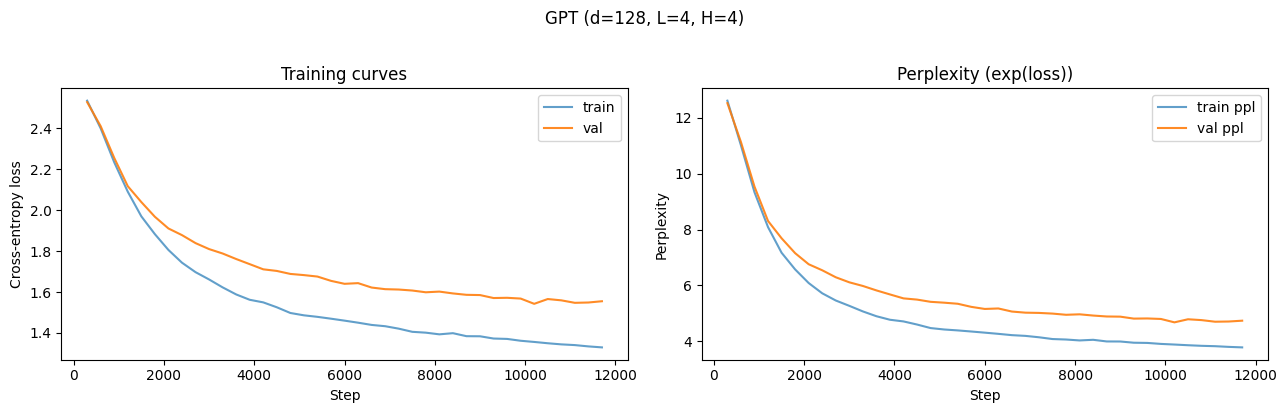

Best val loss       : 1.5424
Best val perplexity : 4.68


In [ ]:
# ── Learning curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

steps = result['step_history']
axes[0].plot(steps, result['train_losses'], label='train', alpha=0.7)
axes[0].plot(steps, result['val_losses'],   label='val',   alpha=0.9)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training curves')
axes[0].legend()

# Perplexity = exp(loss)
axes[1].plot(steps, np.exp(result['train_losses']), label='train ppl', alpha=0.7)
axes[1].plot(steps, np.exp(result['val_losses']),   label='val ppl',   alpha=0.9)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity (exp(loss))')
axes[1].legend()

plt.suptitle(f'GPT (d={MY_CONFIG["d_model"]}, L={MY_CONFIG["n_layers"]}, H={MY_CONFIG["n_heads"]})', y=1.02)
plt.tight_layout()
plt.show()

print(f'Best val loss       : {result["best_val_loss"]:.4f}')
print(f'Best val perplexity : {math.exp(result["best_val_loss"]):.2f}')

In [ ]:
# ── Sample generated text ──────────────────────────────────────────────────
for prompt, temp in [
    ('ROMEO:', 1.0),
    ('ROMEO:', 0.7),
    ('First Citizen:', 1.0),
]:
    print(f'\n--- prompt="{prompt}" temperature={temp} ---')
    print(generate_text(result['model'], tokenizer, prompt,
                        max_new_tokens=300, temperature=temp, top_k=40))
    print()


--- prompt="ROMEO:" temperature=1.0 ---
ROMEO:
Hasting part an, now often gains with be to thee,
Or shall since. And if her cousin you must all.

DUKE VINCENTIO:
I say well, what I'll prevail.
Though I about lerk, be come holy flood.

VALERIA:
Well, thou Bucky!

JULIET:
He there wound be the father our about tors.
Stay
Thee, broke Cominius wrow


--- prompt="ROMEO:" temperature=0.7 ---
ROMEO:
What not the king not I cannot live me to thee.

DUKE OF YORK:
My lord, sir, majesty, I have see, that he may believe
The state of the weaks of my father of a sort thee are him;
The worses, and do it in the patient,
Which cheek by the departial men us struck
To should the desperate of thee and them


--- prompt="First Citizen:" temperature=1.0 ---
First Citizen:
The rough of indeedful mertitude.

CORIOLANUS:
Well, your letter more.

SICINIUS:
A consent too worse of a worth at purposeech'd
And Marcius the present of death drief
And finy enemy time them, in a barted to disgive;
Intime cannot this h

---
## Section 9 — Ablation experiments

### ✏️ TASK 9.1 — Depth vs width ablation

**Question**: For a fixed parameter budget, is it better to go deeper (more layers) or wider (larger d_model)?

**Hypothesis** *(write before running)*:

*(What do you expect? In CNNs, depth seemed more important than width. Is that true for transformers too?)*


shallow-wide: 1.62M params
step 300 | train loss 2.4574 | val loss 2.4722
step 600 | train loss 2.2190 | val loss 2.2389
step 900 | train loss 2.0082 | val loss 2.0609
step 1200 | train loss 1.8688 | val loss 1.9697
step 1500 | train loss 1.7726 | val loss 1.8879
step 1800 | train loss 1.7011 | val loss 1.8488
step 2100 | train loss 1.6425 | val loss 1.8010
step 2400 | train loss 1.5969 | val loss 1.7674
step 2700 | train loss 1.5537 | val loss 1.7269
step 3000 | train loss 1.5199 | val loss 1.7140
step 3300 | train loss 1.4940 | val loss 1.6924
step 3600 | train loss 1.4855 | val loss 1.6609
step 3900 | train loss 1.4598 | val loss 1.6600
step 4200 | train loss 1.4362 | val loss 1.6314
step 4500 | train loss 1.4365 | val loss 1.6164
step 4800 | train loss 1.4157 | val loss 1.6200
step 5100 | train loss 1.3987 | val loss 1.6085
step 5400 | train loss 1.3882 | val loss 1.5951
step 5700 | train loss 1.3882 | val loss 1.5811
step 6000 | train loss 1.3756 | val loss 1.5891
step 6300 | tra

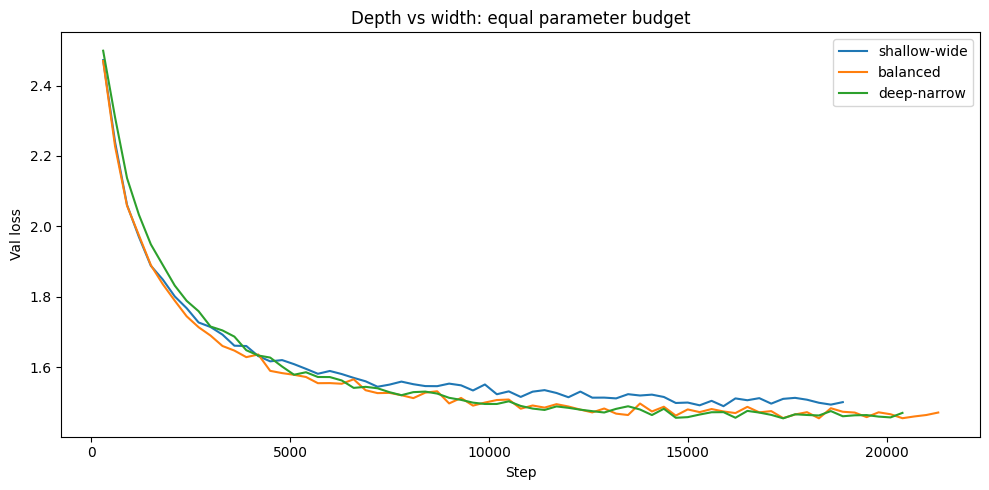

shallow-wide        : best val loss = 1.4891
balanced            : best val loss = 1.4546
deep-narrow         : best val loss = 1.4545


In [ ]:
# Configs with approximately equal parameter counts (~3–5M params each)
# Vary depth vs width while keeping total params roughly fixed
ablation_configs = [
    {'label': 'shallow-wide',  'd_model': 256, 'n_heads': 8, 'n_layers': 2},
    {'label': 'balanced',      'd_model': 192, 'n_heads': 4, 'n_layers': 4},
    {'label': 'deep-narrow',   'd_model': 128, 'n_heads': 4, 'n_layers': 8},
]

ablation_results = {}
SHORT_CONFIG = {**TRAIN_CONFIG, 'epochs': 3, 'patience': 10}

for cfg in ablation_configs:
    label = cfg.pop('label')
    m = GPT(vocab_size=VOCAB_SIZE, context_len=CONTEXT_LEN,
            dropout=0.1, **cfg).to(DEVICE)
    p, _ = estimate_params(VOCAB_SIZE, cfg['d_model'], cfg['n_heads'],
                           cfg['n_layers'], CONTEXT_LEN)
    print(f'\n{label}: {p/1e6:.2f}M params')
    r = train_model(m, train_ds, val_ds, SHORT_CONFIG, DEVICE)
    ablation_results[label] = r
    cfg['label'] = label   # restore

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for label, r in ablation_results.items():
    ax.plot(r['step_history'], r['val_losses'], label=label)
ax.set_xlabel('Step')
ax.set_ylabel('Val loss')
ax.set_title('Depth vs width: equal parameter budget')
ax.legend()
plt.tight_layout()
plt.show()

for label, r in ablation_results.items():
    print(f'{label:20s}: best val loss = {r["best_val_loss"]:.4f}')

In [ ]:
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)

for cfg in ablation_configs:
    label = cfg['label']
    metrics = ablation_results[label].copy()
    metrics.pop('model', None)
    torch.save(metrics, f'results/{label}_metrics.pt')
    print(f'Saved {label}')

Saved shallow-wide
Saved balanced
Saved deep-narrow


**Observation and explanation**:

1. Which configuration achieved the lowest val loss?
2. Did depth or width matter more? Was your hypothesis correct?
3. GPT-3 and most large LLMs use many layers with moderate d_model. Does your experiment support this design choice?

*(Your answers here)*

### ✏️ TASK 9.2 — What does positional encoding do?

Remove positional embeddings entirely and train the same model. What happens?

**Implement `GPT_NoPos`**: identical to `GPT` but `pos_emb` is replaced with a `nn.Identity()` — the model never sees positional information.

In [25]:
class GPT_NoPos(nn.Module):
    """
    GPT without positional embeddings.
    Identical to GPT except pos_emb is not added to token embeddings.

    Everything else — attention, FFN, training — is unchanged.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, context_len,
                 d_ff=None, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
        # YOUR CODE HERE
        # Hint: copy GPT.__init__ but remove the pos_emb line
        self.vocab_size = vocab_size
        self.tok_embd = nn.Embedding(self.vocab_size,d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_blocks = nn.Sequential(*[
            TransformerBlock(d_model,n_heads,d_ff,context_len,dropout)
            for _ in range(n_layers)
        ])
        self.ln_f=nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model,vocab_size,bias=False)

    def forward(self, idx, targets=None):
        # YOUR CODE HERE
        # Hint: copy GPT.forward but use only token_emb(idx), no pos_emb
        B,T = idx.shape
        tok_embd = self.tok_embd(idx)
        x= self.dropout(tok_embd)
        for block in self.attn_blocks:
            x= block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        else:
            loss = F.cross_entropy(logits.view(-1,self.vocab_size),targets.view(-1))
            return logits,loss


    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Training GPT with positional encoding...

Training GPT WITHOUT positional encoding...
step 300 | train loss 2.4733 | val loss 2.4782
step 600 | train loss 2.3777 | val loss 2.3985
step 900 | train loss 2.3167 | val loss 2.3563
step 1200 | train loss 2.2644 | val loss 2.3142
step 1500 | train loss 2.1722 | val loss 2.2264
step 1800 | train loss 2.0683 | val loss 2.1572
step 2100 | train loss 1.9910 | val loss 2.0882
step 2400 | train loss 1.9231 | val loss 2.0395
step 2700 | train loss 1.8704 | val loss 1.9947
step 3000 | train loss 1.8321 | val loss 1.9607
step 3300 | train loss 1.7839 | val loss 1.9223
step 3600 | train loss 1.7610 | val loss 1.9005
step 3900 | train loss 1.7282 | val loss 1.8745
step 4200 | train loss 1.7075 | val loss 1.8652
step 4500 | train loss 1.6923 | val loss 1.8435
step 4800 | train loss 1.6732 | val loss 1.8312
step 5100 | train loss 1.6493 | val loss 1.8262
step 5400 | train loss 1.6442 | val loss 1.8016
step 5700 | train loss 1.6263 | val loss 1.7968
step 

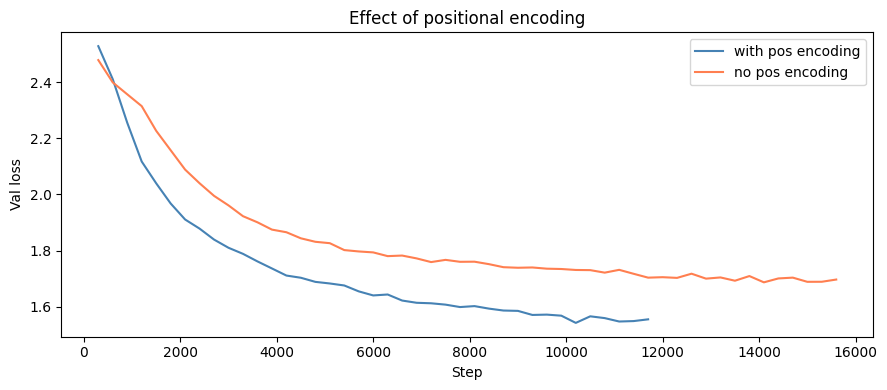

With pos:    best val loss = 1.5424  ppl = 4.68
Without pos: best val loss = 1.6868  ppl = 5.40


In [26]:
print('Training GPT with positional encoding...')
m_with_pos = GPT(**{k: v for k, v in MY_CONFIG.items()}).to(DEVICE)
r_with_pos = result  # reuse from Section 8 if trained already

print('\nTraining GPT WITHOUT positional encoding...')
m_no_pos = GPT_NoPos(**{k: v for k, v in MY_CONFIG.items()}).to(DEVICE)
r_no_pos = train_model(m_no_pos, train_ds, val_ds,
                       {**TRAIN_CONFIG, 'epochs': 10}, DEVICE)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(r_with_pos['step_history'], r_with_pos['val_losses'], label='with pos encoding', color='steelblue')
ax.plot(r_no_pos['step_history'],   r_no_pos['val_losses'],   label='no pos encoding',  color='coral')
ax.set_xlabel('Step')
ax.set_ylabel('Val loss')
ax.set_title('Effect of positional encoding')
ax.legend()
plt.tight_layout()
plt.show()

print(f'With pos:    best val loss = {r_with_pos["best_val_loss"]:.4f}  ppl = {math.exp(r_with_pos["best_val_loss"]):.2f}')
print(f'Without pos: best val loss = {r_no_pos["best_val_loss"]:.4f}  ppl = {math.exp(r_no_pos["best_val_loss"]):.2f}')

In [27]:
os.makedirs('models',  exist_ok=True)
os.makedirs('results', exist_ok=True)
model_path  = 'models/gpt_noPos.pt'
metrics_path = 'results/gpt_noPos_metrics.pt'
result_noPos = r_no_pos.copy()
model_noPos = result_noPos.pop('model')
torch.save(model_noPos.state_dict(), model_path)
torch.save(result_noPos, metrics_path)

**Observation and explanation**:

1. How much did removing positional encoding hurt? Were you surprised by the magnitude?
2. Self-attention is *permutation equivariant* — without positional encoding, shuffling the input tokens produces the same output (shuffled). Why would this be a problem for language modeling?
3. Generate some text from `m_no_pos`. Does the output look different from the model with positional encoding?

*(Your answers here)*

### ✏️ TASK 9.3 — What does the causal mask do?

Train a model without the causal mask — a **non-causal** transformer (like BERT, not GPT). This means every position can attend to every other position, including future tokens.

**Question**: If the model can see future tokens during training, what happens to the loss? To the generated text?

**Hypothesis** *(write before running)*:

*(The model can "cheat" during training — it can look at the answer. What will happen to training loss vs val loss? Will generation work?)*

In [33]:
class MultiHeadSelfAttention_NoCausal(nn.Module):
    """
    Identical to MultiHeadSelfAttention but WITHOUT the causal mask.
    Every position attends to every other position (bidirectional).
    """
    def __init__(self, d_model, n_heads, context_len, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        # YOUR CODE HERE — copy MultiHeadSelfAttention but skip the mask registration
        self.d_head = d_model // n_heads
        self.d_model = d_model
        self.n_heads = n_heads
        self.qkv_proj = nn.Linear(d_model,3*d_model,bias=False)
        self.out_proj = nn.Linear(d_model,d_model,bias = False)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):
        # YOUR CODE HERE — copy the forward but do NOT apply masked_fill
        B,T,_=x.shape
        qkv = self.qkv_proj(x)
        q,k,v = qkv.split(self.d_model,dim=-1)
        q=q.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        k=k.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        v=v.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        scores = (q @ k.transpose(-2,-1))/math.sqrt(self.d_head)
        weights = F.softmax(scores,dim=-1)
        weights = self.attn_dropout(weights)
        out = weights @ v
        out = out.transpose(1,2).contiguous().view(B,T,self.d_model)
        return self.out_proj(out)


class TransformerBlock_NoCausal(nn.Module):
    """
    One transformer layer: Pre-LN attention + Pre-LN FFN, both with residuals.

    Args:
        d_model     (int)
        n_heads     (int)
        d_ff        (int): FFN inner dim, typically 4 * d_model
        context_len (int)
        dropout     (float)
    """
    def __init__(self, d_model, n_heads, d_ff, context_len, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.attn = MultiHeadSelfAttention_NoCausal(d_model,n_heads,context_len,dropout)
        self.ffn =FeedForward(d_model,d_ff,dropout)
        self.dropout = nn.Dropout(dropout)
        self.ln1=nn.LayerNorm(d_model)
        self.ln2=nn.LayerNorm(d_model)

    def forward(self, x):
        """
        Args:
            x: (B, T, d_model)
        Returns:
            x: (B, T, d_model)  — same shape
        """
        # Pseudocode:
        # x = x + self.dropout(self.attn(self.ln1(x)))
        # x = x + self.dropout(self.ffn(self.ln2(x)))
        # return x
        # YOUR CODE HERE
        x = x + self.dropout(self.attn(self.ln1(x)))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x

class GPT_NoCausal(nn.Module):
    """
    GPT with bidirectional attention (no causal mask).
    Uses MultiHeadSelfAttention_NoCausal in every TransformerBlock.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, context_len,
                 d_ff=None, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
        # YOUR CODE HERE
        # Hint: identical to GPT but TransformerBlock should use
        # MultiHeadSelfAttention_NoCausal instead of MultiHeadSelfAttention
        # Easiest approach: either modify TransformerBlock to accept an attn class,
        # or manually build each block here with the right attention module.
        self.vocab_size = vocab_size
        self.context_len = context_len
        self.tok_embd = nn.Embedding(vocab_size,d_model)
        self.pos_embd = nn.Embedding(context_len,d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_blocks = nn.Sequential(*[
            TransformerBlock_NoCausal(d_model,n_heads,d_ff,context_len,dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model,vocab_size,bias=False)

    def forward(self, idx, targets=None):
        # YOUR CODE HERE — same as GPT.forward
        B,T = idx.shape
        tok_embd = self.tok_embd(idx)
        pos = torch.arange(T,device=idx.device)
        pos_embd = self.pos_embd(pos)
        x = self.dropout(tok_embd+pos_embd)
        for block in self.attn_blocks:
            x= block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        else:
            loss = F.cross_entropy(logits.view(-1,self.vocab_size),targets.view(-1))
            return logits,loss

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Training GPT WITHOUT causal mask (bidirectional)...
step 300 | train loss 2.5297 | val loss 2.5298
step 600 | train loss 2.1632 | val loss 2.1831
step 900 | train loss 0.0411 | val loss 0.0415
step 1200 | train loss 0.0245 | val loss 0.0251
step 1500 | train loss 0.0221 | val loss 0.0222
step 1800 | train loss 0.0208 | val loss 0.0218
step 2100 | train loss 0.0211 | val loss 0.0206
step 2400 | train loss 0.0203 | val loss 0.0203
step 2700 | train loss 0.0202 | val loss 0.0202
step 3000 | train loss 0.0189 | val loss 0.0201
step 3300 | train loss 0.0189 | val loss 0.0188
step 3600 | train loss 0.0186 | val loss 0.0188
step 3900 | train loss 0.0184 | val loss 0.0191
step 4200 | train loss 0.0184 | val loss 0.0185
step 4500 | train loss 0.0178 | val loss 0.0187
step 4800 | train loss 0.0181 | val loss 0.0176
step 5100 | train loss 0.0173 | val loss 0.0179
step 5400 | train loss 0.0177 | val loss 0.0177
step 5700 | train loss 0.0172 | val loss 0.0176
step 6000 | train loss 0.0175 | val los

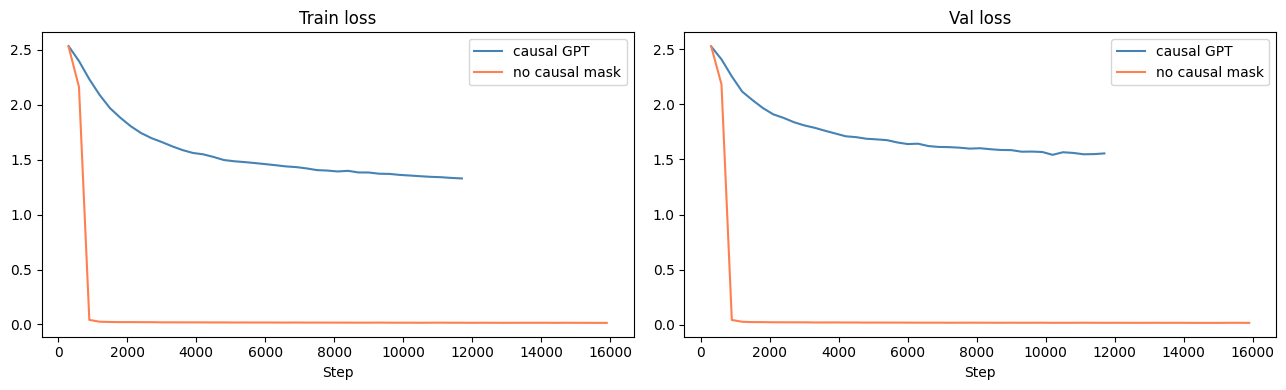

Causal GPT:     train=1.3296  val=1.5424
No causal mask: train=0.0138  val=0.0150

Generated text from no-causal model:
ROMEO:MEMeMRRRReREOMeRRMeeRROfffMedROMeRReeeRRMeReReeRRRRRMRERREReORRERReRORRRedeReeRRedeRRRRRTRReeRRRRRRRRORRRORdeRRRORRRRRRRRRRRR:RRRRRRTWRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR


In [34]:
print('Training GPT WITHOUT causal mask (bidirectional)...')
m_no_causal = GPT_NoCausal(**{k: v for k, v in MY_CONFIG.items()}).to(DEVICE)
r_no_causal = train_model(m_no_causal, train_ds, val_ds,
                          {**TRAIN_CONFIG, 'epochs': 8}, DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key, label in [(axes[0], 'train_losses', 'Train loss'), (axes[1], 'val_losses', 'Val loss')]:
    ax.plot(r_with_pos['step_history'], r_with_pos[key], label='causal GPT', color='steelblue')
    ax.plot(r_no_causal['step_history'],r_no_causal[key],label='no causal mask', color='coral')
    ax.set_title(label)
    ax.set_xlabel('Step')
    ax.legend()
plt.tight_layout()
plt.show()

print(f'Causal GPT:     train={r_with_pos["train_losses"][-1]:.4f}  val={r_with_pos["best_val_loss"]:.4f}')
print(f'No causal mask: train={r_no_causal["train_losses"][-1]:.4f}  val={r_no_causal["best_val_loss"]:.4f}')

# Try to generate with the no-causal model
print('\nGenerated text from no-causal model:')
print(generate_text(r_no_causal['model'], tokenizer, 'ROMEO:', max_new_tokens=200))

In [35]:
model_path  = 'models/gpt_noCausal.pt'
metrics_path = 'results/gpt_noCausal_metrics.pt'
result_noCausal = r_no_causal.copy()
model_noCausal = result_noCausal.pop('model')
torch.save(model_noCausal.state_dict(), model_path)
torch.save(result_noCausal, metrics_path)

**Observation and explanation**:

1. Was the non-causal model's training loss lower? Why — what advantage does seeing future tokens give?
2. How did its *validation* loss compare? Does it generalize better or worse?
3. Look at the generated text from the no-causal model. Is it coherent? Why does generation fail (or degrade) without the causal mask, even if training loss was low?
4. This is exactly the difference between GPT (causal, generative) and BERT (non-causal, for classification/understanding). In your own words, explain when you would use each.

*(Your answers here)*

---
## Section 10 — Visualizing attention

### ✏️ TASK 10.1 — Implement `get_attention_maps`

**What it does**: Extract the attention weight matrices from every layer and head for a given input sequence, and visualize them as heatmaps.

**Algorithm**:
- Register forward hooks on each `MultiHeadSelfAttention` layer
- Each hook saves the `weights` tensor (shape `(1, n_heads, T, T)`) before the output projection
- Run a forward pass, then remove all hooks
- Plot the resulting matrices: rows = position attending, columns = position attended to

**Hint**: You need to slightly modify your `MultiHeadSelfAttention.forward` to store the attention weights (or add an optional `return_attn` flag).

In [37]:
@torch.no_grad()
def get_attention_maps(model, tokenizer, text_prompt, device=DEVICE):
    """
    Visualize attention weights for all layers and heads on a short prompt.

    Args:
        model       (GPT): trained model
        tokenizer   (CharTokenizer)
        text_prompt (str): short string to visualize (keep under 30 chars for readability)
        device
    """
    model.eval()
    tokens = tokenizer.encode(text_prompt)
    T      = len(tokens)
    idx    = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    # Collect attention weights via hooks
    attn_weights = []
    handles = []

    # YOUR CODE HERE
    # 1. Find all MultiHeadSelfAttention modules in model
    # 2. For each, register a hook on the attention weights
    #    (you may need to modify MultiHeadSelfAttention to expose weights)
    # 3. Run forward pass
    # 4. Remove all hooks
    # 5. Plot a grid of heatmaps: rows=layers, columns=heads
    model(idx)
    for block in model.attn_blocks:
        w = block.attn.last_attn_weights  # (1, n_heads, T, T)
        attn_weights.append(w.squeeze(0).cpu())  # (n_heads, T, T)
    n_layers = len(attn_weights)
    n_heads  = attn_weights[0].shape[0]
    chars    = [tokenizer.decode([t]) for t in tokens]

    fig, axes = plt.subplots(n_layers, n_heads,
                             figsize=(3 * n_heads, 3 * n_layers))
    for layer_idx, w in enumerate(attn_weights):
        for head_idx in range(n_heads):
            ax = axes[layer_idx, head_idx]
            # w[head_idx]: (T, T)
            ax.imshow(w[head_idx].numpy(), vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(T))
            ax.set_yticks(range(T))
            ax.set_xticklabels(chars, fontsize=7)
            ax.set_yticklabels(chars, fontsize=7)
            ax.set_title(f'L{layer_idx} H{head_idx}', fontsize=8)

    plt.suptitle(f'Attention maps: "{text_prompt}"', y=1.02)
    plt.tight_layout()
    plt.show()


# Run on your best trained model
SHORT_PROMPT = 'ROMEO: I love thee'
get_attention_maps(result['model'], tokenizer, SHORT_PROMPT)

AttributeError: 'MultiHeadSelfAttention' object has no attribute 'last_attn_weights'

**Observation**: Look at the attention maps.

1. Do different heads attend to different patterns? Describe what you see in at least 2 heads.
2. You should see a diagonal pattern (each token attending most to itself) and a lower-triangular structure (causal mask). What other patterns appear?
3. Are there heads that appear to focus on recent tokens vs. heads that look further back?

*(Your answers here)*

---
## Section 11 — Final reflection

Answer all of these. They connect your implementation directly to how LLMs work in practice.

1. **`d_ff = 4 * d_model`**: Your ablation results (or reasoning) should give you an answer: why this ratio? What happens if you use `d_ff = d_model` (no expansion)? What about `8 * d_model`?

2. **Scaling**: GPT-3 has 96 layers, d_model=12288, 96 heads, context_len=2048. Your model has perhaps 3–6 layers and d_model=128–256. What changes qualitatively as you scale? Why can't you just train your 5M-param model longer to match GPT-3?

3. **Context length tradeoff**: You used context_len=128. What is the computational cost of doubling it to 256? (Hint: the attention matrix is T×T — what happens to it?) This is why long-context models (Claude with 200k context) are hard to build.

4. **LayerNorm vs BatchNorm**: You used LayerNorm throughout. CNNs typically use BatchNorm. Why is BatchNorm inappropriate for sequences? (Hint: think about what BatchNorm normalizes over vs LayerNorm.)

5. **Connection to fine-tuning (Phase 2 preview)**: Your model learned to predict Shakespeare. In Phase 2, you will take a pretrained LLM (Llama 3.1 8B) and fine-tune it on a specific task using LoRA. LoRA works by adding small low-rank matrices to the Q and K projection weights in attention. Based on what you've built here: which layers' Q/K matrices do you think matter most for fine-tuning a specific task? Why?

*(Your answers here)*

---
## Bonus A — Temperature sampling analysis

Generate text at temperatures 0.5, 0.8, 1.0, 1.2, and 1.5. For each:
1. Paste a 200-character sample
2. Describe the qualitative difference — how does creativity vs. coherence change?
3. Plot the token probability distribution at one position for each temperature (before and after applying temperature)

This is not just a toy exercise — understanding temperature is directly relevant to serving LLMs in production. Anthropic uses temperature (and top-p/top-k) sampling in every Claude response.

In [38]:
# YOUR CODE HERE — generate at multiple temperatures and analyze
for temp in [0.5, 0.8, 1.0, 1.2, 1.5]:
    print(f'\n=== temperature = {temp} ===')
    print(generate_text(result['model'], tokenizer, 'ROMEO:', max_new_tokens=200, temperature=temp))


=== temperature = 0.5 ===
ROMEO:
I have the proclaim of the world and the odds
Deserves of his passion'd in the bloody of Romeo?

KING RICHARD II:
And that the other words and the father stoop of the strike.

KING RICHARD II:
What y

=== temperature = 0.8 ===
ROMEO:
Ay, sweet me, God see him to the wife for this heart
And the head in thy house embraced them be drum.

LEONTES:
No, were come my life is be gone?

ESCALUS:
No, if I will.

ANGELO:
You do the prove.



=== temperature = 1.0 ===
ROMEO:
No, heap in children and fair much I were death:
Therefore light in my bassard which yours sorrows.

Post:
He shall out in this citizens are but friend,
When is streaming to you, fond a Ramio.

LADY 

=== temperature = 1.2 ===
ROMEO:
I do you favour handst you shall perforce gpeece
Sounded ancient Turns. Coved, you.

SICINIUS:
Go.

QUEEN:
O, your, hurt need craftle, if I propheed;
We where in the kind that me? Revoltern it.

ISAB

=== temperature = 1.5 ===
ROMEO:
supplel my lifts,
Would me wat

---
## Bonus B — Compare to nanoGPT

Now that you have finished your implementation, look at Andrej Karpathy's nanoGPT:  
https://github.com/karpathy/nanoGPT/blob/master/model.py

Write a brief comparison (in the cell below) answering:
1. What did you implement the same way?
2. What did Karpathy do differently? (Look especially at weight initialization, the `lm_head` weight tying trick, and `Flash Attention`.)
3. What is weight tying (`lm_head.weight = token_emb.weight`)? Why does it save parameters and potentially help training?
4. What is Flash Attention? Why is it important for long contexts?

*(Your comparison here)*